# Lab_2: Using simple classification methods for solving classification problem

# Anzhelika Mazurenko CS32
# Task:
1. Do data preprocessing & data visualization as it was in the 1st lab work
2. Solve classification problem for the selected dataset.
3. Use `examples/fisher_irises.ipynb` as baseline for your experiments
4. Try to optimize hyperparameters of some model

# Datasets for classification
1. [Mushroom Classification](https://www.kaggle.com/datasets/uciml/mushroom-classification)
2. [Fetal Health Classification](https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification)
3. [Glass Classification](https://www.kaggle.com/datasets/uciml/glass)
4. [Gender Classification Dataset](https://www.kaggle.com/datasets/elakiricoder/gender-classification-dataset)
5. [Weather Type Classification](https://www.kaggle.com/datasets/nikhil7280/weather-type-classification)
6. [Star Type Classification / NASA](https://www.kaggle.com/datasets/brsdincer/star-type-classification)
7. [Happiness Classification Dataset](https://www.kaggle.com/datasets/priyanshusethi/happiness-classification-dataset)
8. [NASA: Asteroids Classification
Data Collected from NASA API](https://www.kaggle.com/datasets/shrutimehta/nasa-asteroids-classification)
9. [CS:GO Round Winner Classification](https://www.kaggle.com/datasets/christianlillelund/csgo-round-winner-classification)
10. [Heart Disease Classification Dataset](https://www.kaggle.com/datasets/bharath011/heart-disease-classification-dataset)
11. [Early Classification of Diabetes](https://www.kaggle.com/datasets/andrewmvd/early-diabetes-classification)
12. [Credit Risk Classification Dataset](https://www.kaggle.com/datasets/praveengovi/credit-risk-classification-dataset)

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [71]:
df = pd.read_csv('gender_classification.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [72]:
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [73]:
print(df.isnull().sum())
print(df.describe())

# Унікальні значення в цільовому стовпці
print(df['gender'].value_counts())

long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64
         long_hair  forehead_width_cm  forehead_height_cm    nose_wide  \
count  5001.000000        5001.000000         5001.000000  5001.000000   
mean      0.869626          13.181484            5.946311     0.493901   
std       0.336748           1.107128            0.541268     0.500013   
min       0.000000          11.400000            5.100000     0.000000   
25%       1.000000          12.200000            5.500000     0.000000   
50%       1.000000          13.100000            5.900000     0.000000   
75%       1.000000          14.000000            6.400000     1.000000   
max       1.000000          15.500000            7.100000     1.000000   

         nose_long    lips_thin  distance_nose_to_lip_long  
count  5001

In [74]:
label_encoder = LabelEncoder()
df["gender"] = label_encoder.fit_transform(df["gender"])
df.head()
# LabelEncoder перетворює:
# 'Female' → 0
# 'Male' → 1

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0


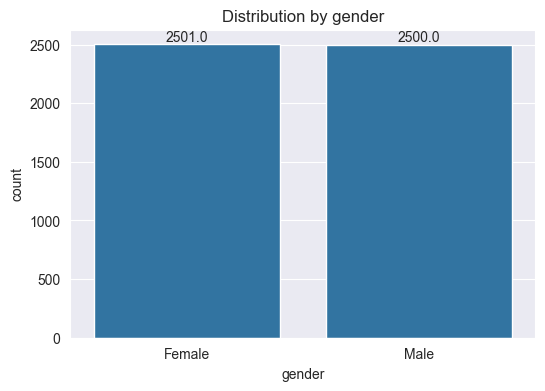

In [75]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='gender')
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Distribution by gender')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')
plt.show()

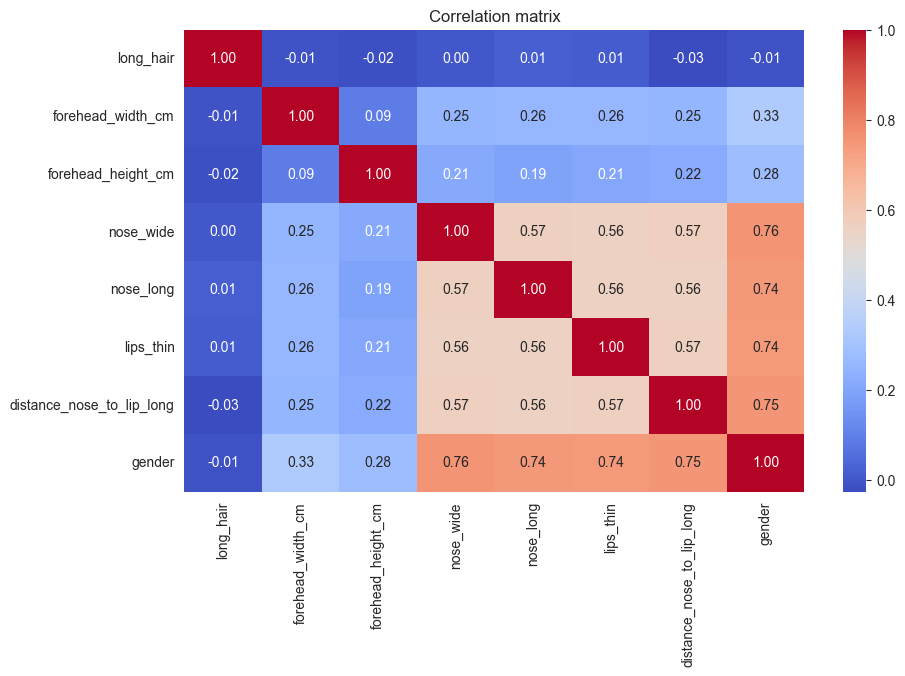

In [76]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

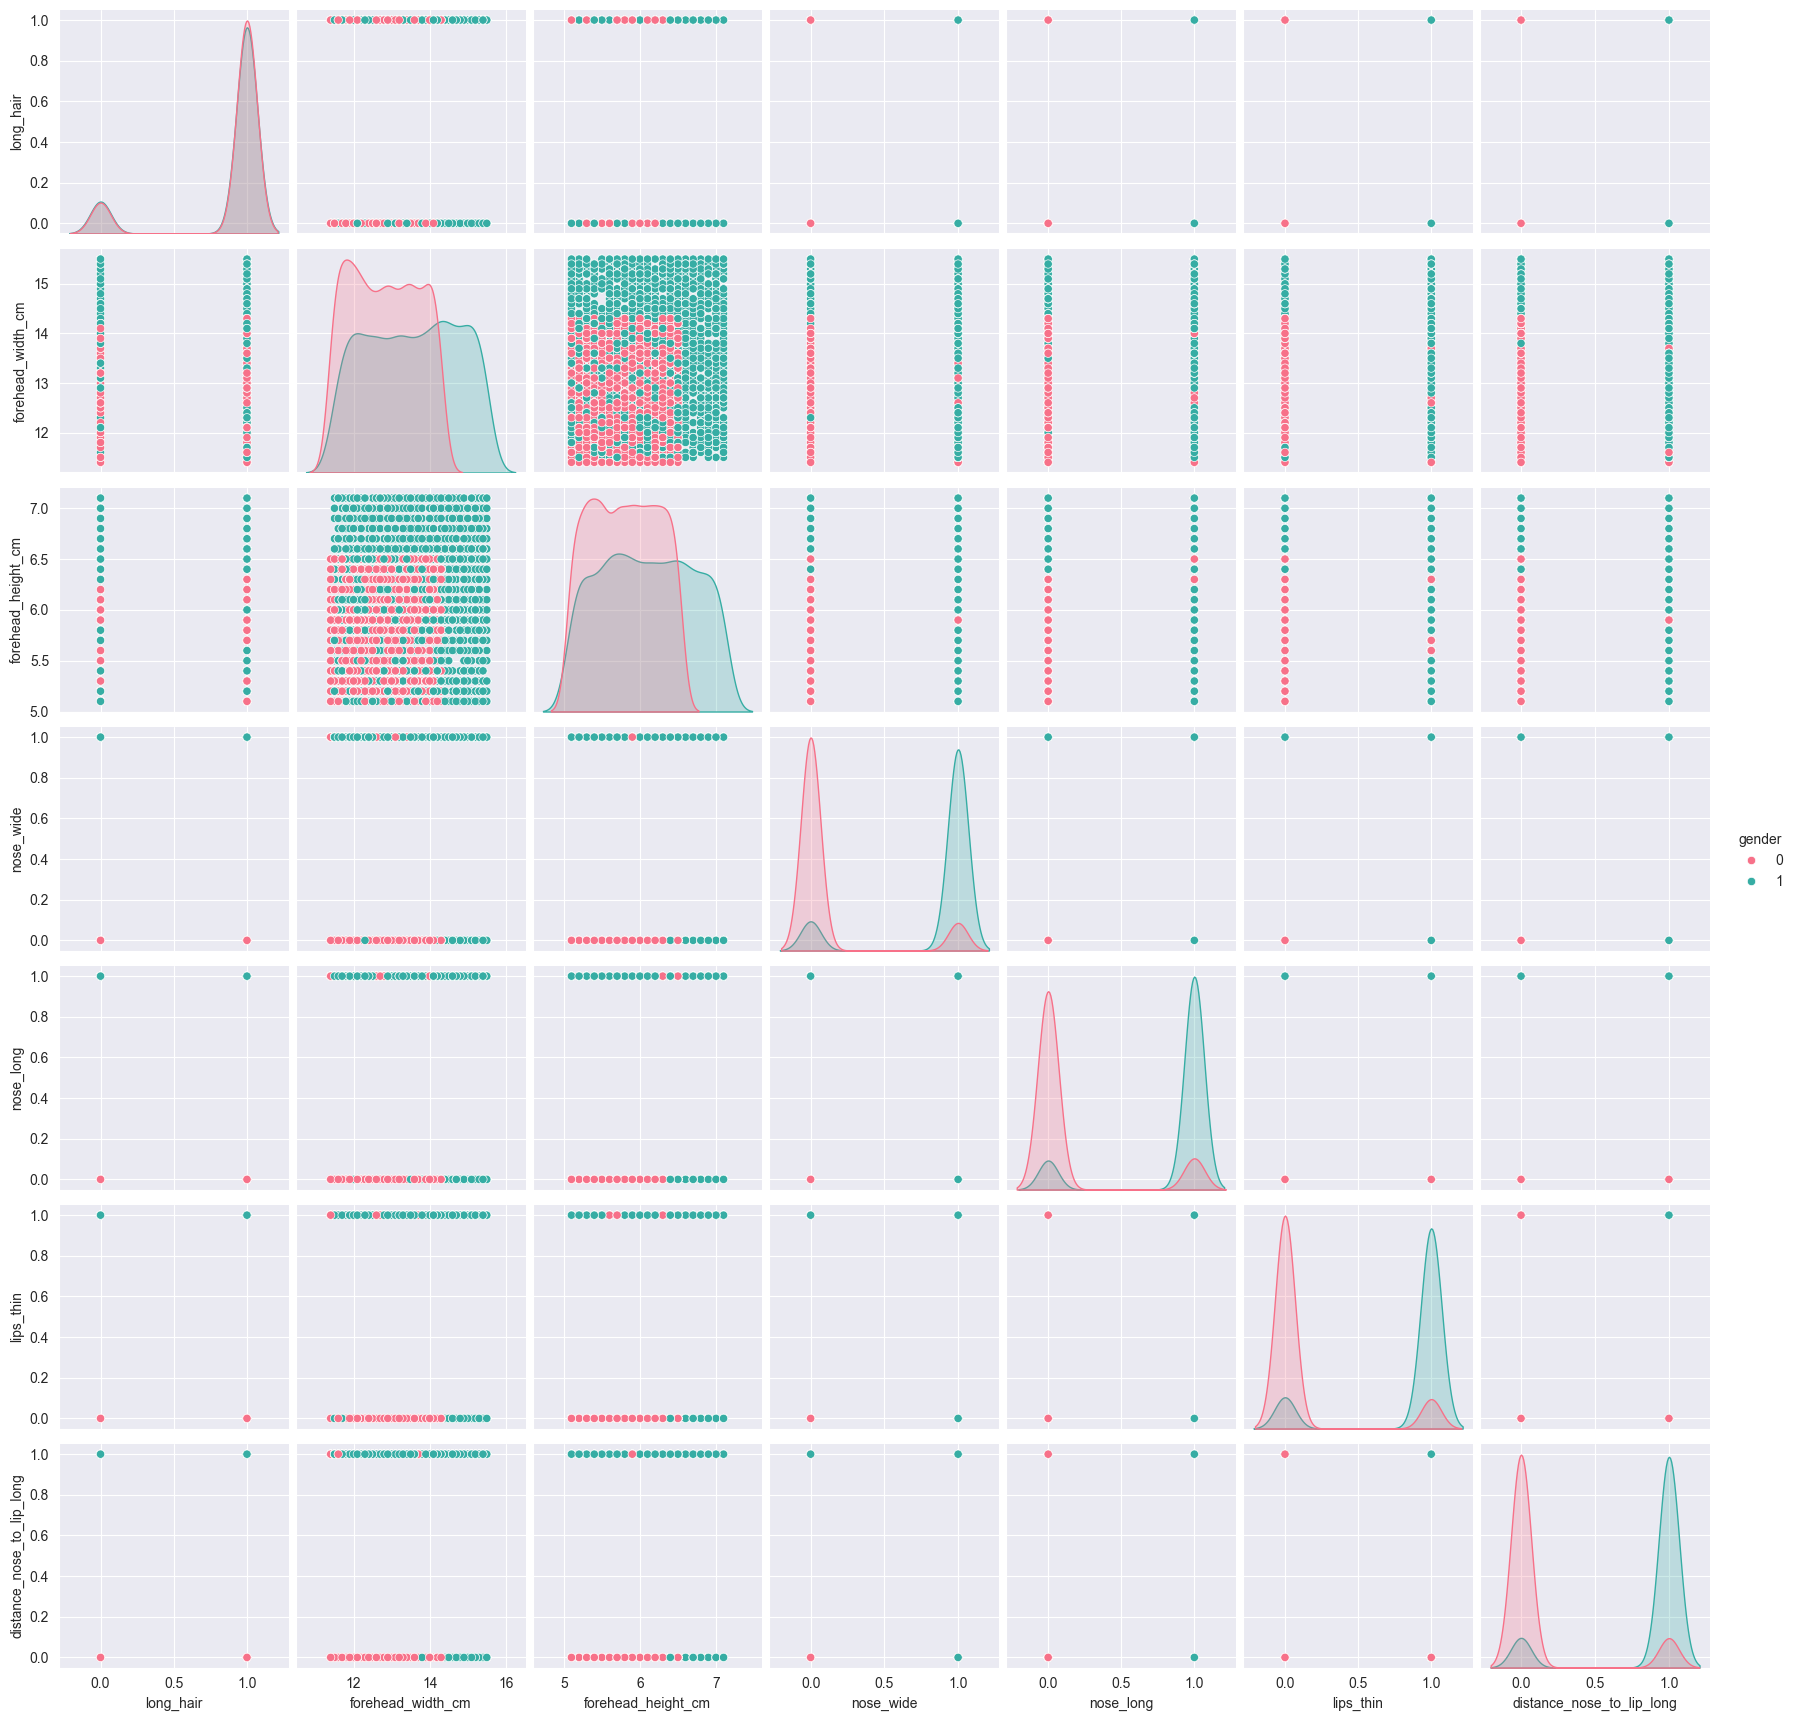

In [77]:
sns.pairplot(df, hue='gender', palette='husl')
plt.show()

In [78]:
X = df.drop('gender', axis=1)
y = df['gender']

# Розбиття на тренувальну і тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
# Метрики класифікації
def metrics(test, pred):
    accuracy = accuracy_score(test, pred)
    precision = precision_score(test, pred)
    recall = recall_score(test, pred)
    f1 = f1_score(test, pred)

    print(f"Accuracy: {accuracy:.2f}") #Accuracy (Точність) – частка правильних передбачень серед усіх.
    print(f"Precision: {precision:.2f}") #Precision (Прецизія) – частка правильних позитивних передбачень (наскільки модель "впевнено" передбачає "Male").
    print(f"Recall: {recall:.2f}") #Recall (Повнота) – частка виявлених позитивних випадків серед усіх фактичних позитивних
                                                        # (чи виявлено всіх "Male").
    print(f"F1 Score: {f1:.2f}") #F1 Score – середнє гармонійне між precision і recall, хороша метрика, коли дані незбалансовані.

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Матриця плутанини
def plot_confusion_matrix(test, pred):
    cm = confusion_matrix(test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=["Female", "Male"],
                yticklabels=["Female", "Male"])
    plt.xlabel("Forecast")
    plt.ylabel("True meaning")
    plt.title("Confusion matrix")
    plt.show()


# ROC-крива
def plot_roc_curve(predicted_probabilities, output_test):
    fpr, tpr, _ = roc_curve(output_test, predicted_probabilities)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color="red", lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC-curve")
    plt.legend(loc="lower right")
    plt.show()


Logistic Regression:
Accuracy: 0.96
Precision: 0.97
Recall: 0.95
F1 Score: 0.96


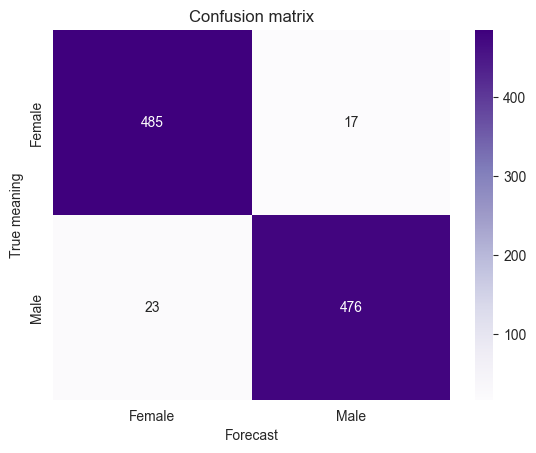

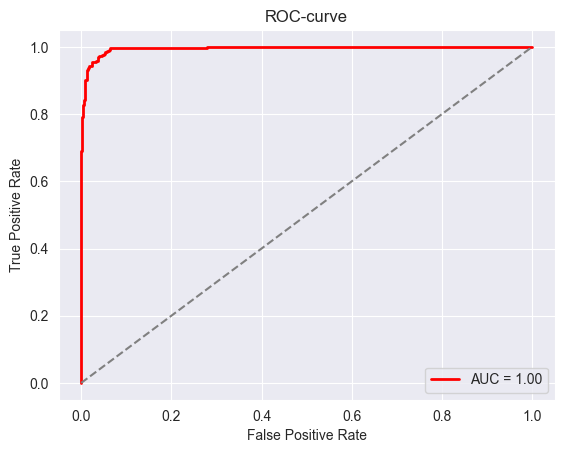


Decision Tree Classifier:
Accuracy: 0.95
Precision: 0.96
Recall: 0.95
F1 Score: 0.95


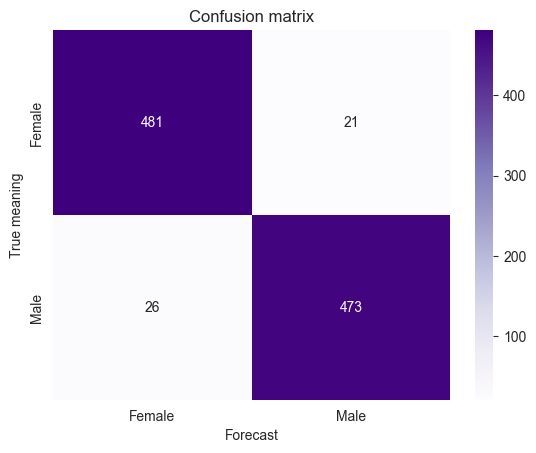

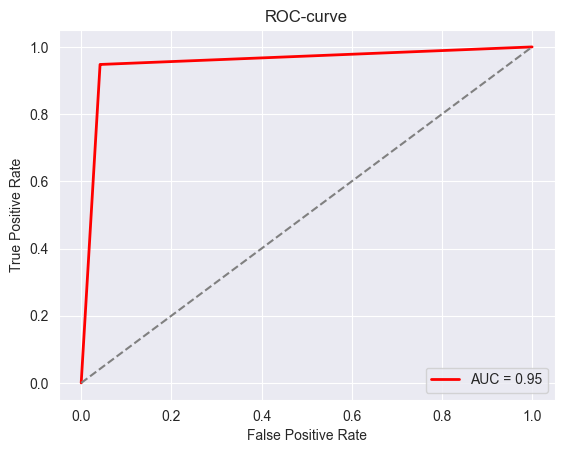


Random Forest Classifier:
Accuracy: 0.96
Precision: 0.96
Recall: 0.96
F1 Score: 0.96


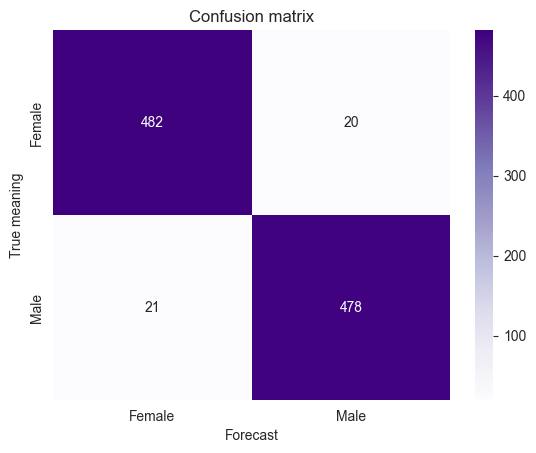

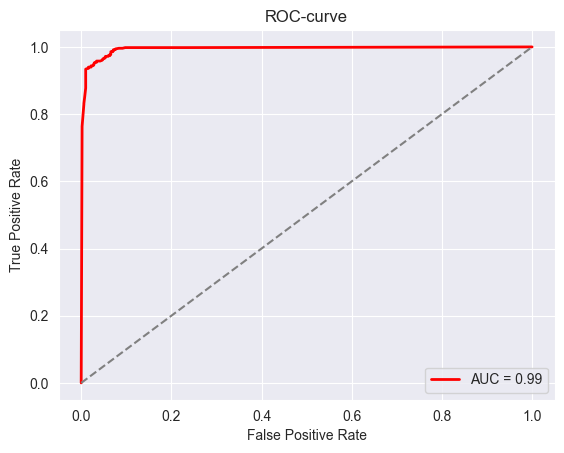

In [80]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree Classifier": DecisionTreeClassifier(), #Дерево рішень
    "Random Forest Classifier": RandomForestClassifier() #Випадковий ліс
}

for name, model in models.items():
    print(f"\n{name}:")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred)
    plot_roc_curve(model.predict_proba(X_test)[:, 1], y_test)

Logistic Regression має AUC = 1.00 — модель ідеально розділяє класи.

Random Forest близький до ідеального з AUC = 0.99.

Decision Tree трохи гірший, але все ще дуже хороший (AUC = 0.95).


Best params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best accuracy in cross-validation: 0.977

Accuracy after tuning: 0.965034965034965
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       502
           1       0.98      0.95      0.96       499

    accuracy                           0.97      1001
   macro avg       0.97      0.96      0.97      1001
weighted avg       0.97      0.97      0.97      1001



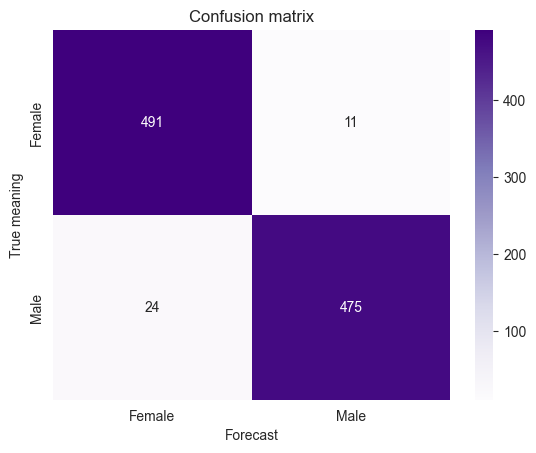

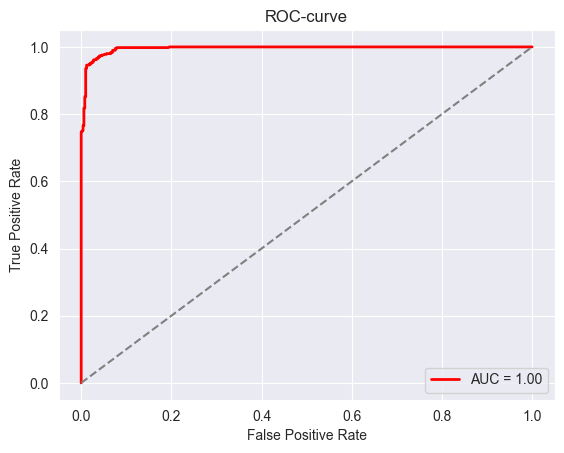

In [81]:
# Параметри для перебору
param_grid = {
    'n_estimators': [50, 100, 200],          # Кількість дерев у лісі
    'max_depth': [None, 5, 10],              # Максимальна глибина дерева (None – без обмежень)
    'min_samples_split': [2, 5, 10]          # Мінімальна кількість зразків для розбиття вузла
}

# Пошук з крос-валідацією
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train, y_train) #перебирає всі комбінації параметрів, навчає модель та обчислює точність на крос-валідації.

# Найкраща модель
print("\nBest params:", grid_search.best_params_)
print("Best accuracy in cross-validation:", grid_search.best_score_)

# Повторна оцінка на тестовій вибірці
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nAccuracy after tuning:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
plot_confusion_matrix(y_test, y_pred_best)
plot_roc_curve(best_model.predict_proba(X_test)[:, 1], y_test)